# PToTR Paper Case Study 01: Tensor Autoregression with the Integrated Crisis Early Warning System (ICEWS) Dataset 

## Poisson-response Tensor-on-Tensor Regression (PToTR)

This example illustrates the use of Poisson-response Tensor-on-Tensor Regression (PToTR) for performing tensor autoregression on the ICEWS databased and appears as a case study in the following paper:

Llosa-Vite, C., & Dunlavy, D. M. (2026). 
*Poisson-response Tensor-on-Tensor Regression and Applications.* 
[arXiv:2604.07377](https://arxiv.org/abs/2604.07377).



### Import dependencies

In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import pyttb as ttb
import matplotlib.pyplot as plt

from ptotr_paper_functions import (
    build_autoregression_data,
    fit_ptotr_ranks,
)

### Load Data

- This data was created by the notebook `ptotr-paper-01-icews-01-data.ipynb`

In [2]:
Z = ttb.import_data("data/icews_tensor_data.tns")
Z_np = Z.full().data

print(type(Z_np))
print(Z_np.shape)

<class 'numpy.ndarray'>
(25, 25, 4, 548)


### Construct X and Y for Autoregression

In [3]:
X_np, Y_np = build_autoregression_data(Z_np)

print("X:", X_np.shape)
print("Y:", Y_np.shape)

X = ttb.tensor(X_np)
Y = ttb.tensor(Y_np)

X: (25, 25, 4, 3, 543)
Y: (25, 25, 4, 543)


### Fitting the PToTR model

In [4]:
%%time

cp_ranks = range(1, 31)

results = fit_ptotr_ranks(
    X,
    Y,
    ranks=cp_ranks,
    ninit=48,
    nit=10, #100
    fit_tol=1e-8,
    n_jobs=48,
    output_dir='../results',
)



rank= 1 | init=  1/48 | loglik=-8.489116e+06
rank= 1 | init=  2/48 | loglik=-8.486374e+06
rank= 1 | init=  3/48 | loglik=-8.486965e+06
rank= 1 | init=  4/48 | loglik=-8.485834e+06
rank= 1 | init=  5/48 | loglik=-8.487403e+06
rank= 1 | init=  6/48 | loglik=-8.486643e+06
rank= 1 | init=  7/48 | loglik=-8.486431e+06
rank= 1 | init=  8/48 | loglik=-8.486834e+06
rank= 1 | init=  9/48 | loglik=-8.485954e+06
rank= 1 | init= 10/48 | loglik=-8.485426e+06
rank= 1 | init= 11/48 | loglik=-8.485889e+06
rank= 1 | init= 12/48 | loglik=-8.487076e+06
rank= 1 | init= 13/48 | loglik=-8.486673e+06
rank= 1 | init= 14/48 | loglik=-8.485981e+06
rank= 1 | init= 15/48 | loglik=-8.486664e+06
rank= 1 | init= 16/48 | loglik=-8.485837e+06
rank= 1 | init= 17/48 | loglik=-8.485673e+06
rank= 1 | init= 18/48 | loglik=-8.486581e+06
rank= 1 | init= 19/48 | loglik=-8.488673e+06
rank= 1 | init= 20/48 | loglik=-8.486238e+06
rank= 1 | init= 21/48 | loglik=-8.486737e+06
rank= 1 | init= 22/48 | loglik=-8.486446e+06
rank= 1 | 

### Reading the Gaussian models and displaying

- The files `cp_res.csv` and `op_res.csv` correspond to Gaussian autoregressive ToTR  models that were fit using the `totr` R package.
- For reproducibility of these files, see https://github.com/carlos-llosa/totr/tree/main/vignettes/autoregression
- The file `ptotr_res.csv` was generated in this notebook, in the previous cell

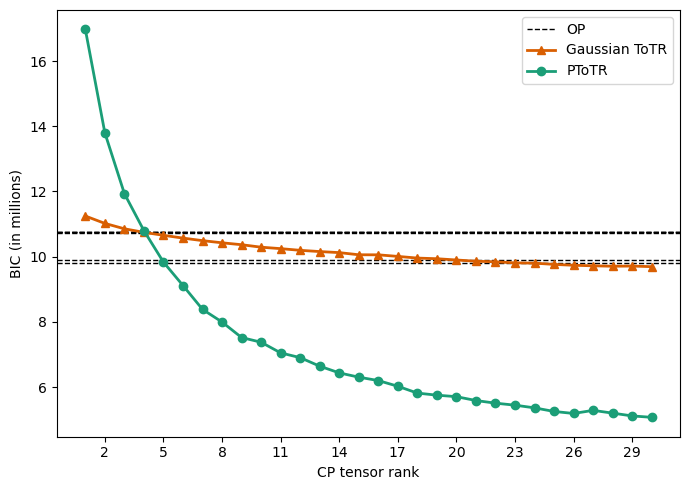

In [5]:

# read BICs
cp_res = pd.read_csv("../results/cp_res.csv")
op_res = pd.read_csv("../results/op_res.csv")
ptotr_res = pd.read_csv("../results/ptotr_res.csv")

#display
fig, ax = plt.subplots(figsize=(7, 5))
scale = 1e6

# OP-based ToTR: one horizontal line per permutation
for i, bic in enumerate(op_res["bic"]):
    ax.axhline(bic / scale,linestyle="--",linewidth=1,label="OP" if i == 0 else None, c = "k")

# Gaussian ToTR
ax.plot(cp_res["rank"],cp_res["bic"] / scale,marker="^",linewidth=2,label="Gaussian ToTR",c = "#d95f02")

# PToTR
ax.plot(ptotr_res["rank"],ptotr_res["bic"] / scale,marker="o",linewidth=2,label="PToTR",c = "#1b9e77")

# Formatting 
ax.set_xlabel("CP tensor rank")
ax.set_ylabel("BIC (in millions)")
ax.set_xticks(range(2, 30, 3))
ax.legend()
fig.tight_layout()
plt.show()